In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import petals

X_train, y_train = petals.training_data(N=4, seed=37)
X_test, y_test = petals.training_data(N=1000, seed=42)

print(X_train.shape, y_train.shape)

(4, 5) (4,)


In [29]:
for x, target in zip(X_train, y_train):
    print(*x, "->", target, sep="\t")

4	5	4	5	6	->	8
3	4	4	3	6	->	4
1	6	1	1	4	->	0
3	5	1	5	3	->	12


In [22]:
# Count data
def counts(X):
    return np.array([np.bincount(row, minlength=7)[1:7] for row in X])
    
C_train = counts(X_train)
C_test = counts(X_test)

In [32]:
for x, target in zip(C_train, y_train):
    print(*x, "|", target, sep="\t")

0	0	0	2	2	1	|	8
0	0	2	2	0	1	|	4
3	0	0	1	0	1	|	0
1	0	2	0	2	0	|	12


In [23]:
solution, residuals, rank, singular_values = np.linalg.lstsq(C_train, y_train, rcond=None)
solution

array([ 2.69662921e-02, -2.22044605e-16,  1.99325843e+00,  9.43820225e-02,
        3.99325843e+00, -1.75280899e-01])

In [24]:
# predict the number of petals from the fitted coefficients
y_test_hat = C_test @ solution
y_test_hat.shape

(1000,)

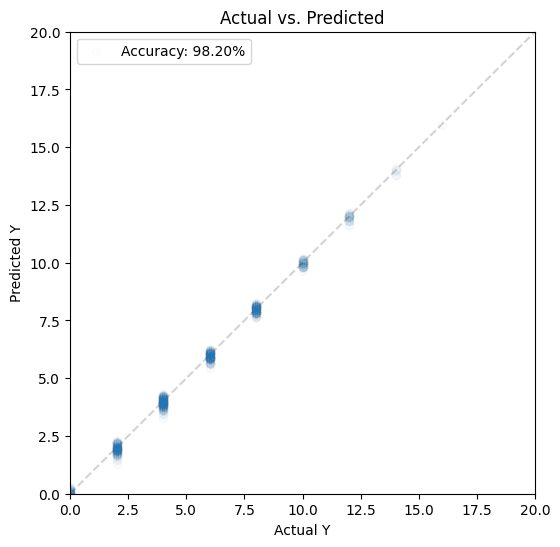

In [25]:
# Actual vs. Predicted Plot
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_hat, alpha=10/X_test.shape[0])
plt.xlabel("Actual Y")
plt.ylabel("Predicted Y")
plt.title("Actual vs. Predicted")
plt.plot([0, 20], [0, 20], '--', color="lightgrey", zorder=0)

plt.ylim(0, 20)
plt.xlim(0, 20)

accuracy = np.mean(y_test == np.rint(y_test_hat))

plt.legend([f'Accuracy: {accuracy*100:.2f}%'])